# Guardar todos los archivos

In [1]:
import os
import numpy as np

# Ruta donde están los archivos LVL2_MX_PY.txt
root_dir = r"C:/Nacho/Universidad/Prácticas Raman/LIBS_QUANTIFICATION_INTA/Spectra/FinalSamples/Level2"


In [2]:
# Se guardarán aquí:
wavelengths = None            # array 1D con las longitudes de onda del primer archivo válido
intensity_cols = []           # lista de arrays 1D con las intensidades de cada archivo
filenames = []                # lista de nombres de archivos cargados, en orden

In [ ]:
# Recorremos MX=1..27 y PY=1..3 en orden numérico
for mx in range(1, 28):
    for py in range(1, 4):
        fname = f"LVL2_M{mx}_P{py}.txt"
        fpath = os.path.join(root_dir, fname)
        try:
            # Cargar dos columnas: wave, intensity
            data = np.loadtxt(fpath, delimiter=',')
            wave = data[:, 0]
            spec = data[:, 1]
            
            # Si es el primer archivo válido, guardamos las longitudes
            if wavelengths is None:
                wavelengths = wave.copy()
            else:
                # Chequeo rápido: que coincidan los ejes
                if not np.allclose(wavelengths, wave):
                    raise ValueError(f"El eje de longitudes no coincide en {fname}")
            
            # Añadimos la columna de intensidades y el nombre
            intensity_cols.append(spec)
            filenames.append(fname)
        except Exception:
            # No existe el archivo o hay error: lo ignoramos
            continue
# Ahora componemos la matriz (N, k)
if intensity_cols:
    intensity_matrix = np.column_stack(intensity_cols)  # shape (N, k)
else:
    intensity_matrix = np.empty((0, 0))


In [ ]:
# Mostramos resultados
# intensity_matrix: shape (N, k)
# filenames: list of length k, e.g. ['LVL2_1_1.txt', 'LVL2_1_2.txt', …]
print("Archivos cargados en orden:")
print(filenames)
print(f"\nLongitudes de onda (N={wavelengths.size if wavelengths is not None else 0}):")
print(wavelengths)
print(f"\nMatriz de intensidades (shape={intensity_matrix.shape}):")
print(intensity_matrix)

Archivos cargados en orden:
['LVL2_M1_P1.txt', 'LVL2_M1_P2.txt', 'LVL2_M1_P3.txt', 'LVL2_M2_P1.txt', 'LVL2_M2_P2.txt', 'LVL2_M2_P3.txt', 'LVL2_M3_P1.txt', 'LVL2_M3_P2.txt', 'LVL2_M3_P3.txt', 'LVL2_M4_P1.txt', 'LVL2_M4_P2.txt', 'LVL2_M4_P3.txt', 'LVL2_M5_P1.txt', 'LVL2_M5_P2.txt', 'LVL2_M5_P3.txt', 'LVL2_M6_P1.txt', 'LVL2_M6_P2.txt', 'LVL2_M6_P3.txt', 'LVL2_M7_P1.txt', 'LVL2_M7_P2.txt', 'LVL2_M7_P3.txt', 'LVL2_M8_P1.txt', 'LVL2_M8_P2.txt', 'LVL2_M8_P3.txt', 'LVL2_M9_P1.txt', 'LVL2_M9_P2.txt', 'LVL2_M9_P3.txt', 'LVL2_M10_P1.txt', 'LVL2_M10_P2.txt', 'LVL2_M10_P3.txt', 'LVL2_M11_P1.txt', 'LVL2_M11_P2.txt', 'LVL2_M11_P3.txt', 'LVL2_M12_P1.txt', 'LVL2_M12_P2.txt', 'LVL2_M12_P3.txt', 'LVL2_M13_P2.txt', 'LVL2_M13_P3.txt', 'LVL2_M14_P1.txt', 'LVL2_M14_P2.txt', 'LVL2_M14_P3.txt', 'LVL2_M15_P2.txt', 'LVL2_M15_P3.txt', 'LVL2_M16_P1.txt', 'LVL2_M16_P2.txt', 'LVL2_M16_P3.txt', 'LVL2_M17_P1.txt', 'LVL2_M17_P2.txt', 'LVL2_M17_P3.txt', 'LVL2_M18_P1.txt', 'LVL2_M18_P2.txt', 'LVL2_M18_P3.txt', 'LVL2_M19_

In [19]:
out_wln = os.path.join(root_dir, f"LVL2_Wavelengths.txt")
out_spec = os.path.join(root_dir, f"LVL2_All_Spectra.txt")

# Write a header line with the original file‑names, tab‑delimited
header = "\t".join(filenames)


# Save the Spectra matrix
np.savetxt(out_spec,intensity_matrix,
    fmt="%.6e",        # scientific notation, 6 decimals
    delimiter="\t",
    header=header,
    comments=""         # don’t prefix the header with “#”
)

# Save the Wavelengths matrix
np.savetxt(out_wln,wavelengths,
    fmt="%.6e",        # scientific notation, 6 decimals
    delimiter="\t",
    comments=""         # don’t prefix the header with “#”
)

# Leer los archivos

In [1]:
import os
import numpy as np
root_dir = r"../Spectra/FinalSamples"
dir_wln = os.path.join(root_dir, f"Level2/LVL2_Wavelengths.txt")
dir_spec = os.path.join(root_dir, f"Level2/LVL2_All_Spectra.txt")
with open(dir_spec, "r") as f:
    first_line = f.readline().strip()
column_names = first_line.split("\t")
all_Spectra = np.genfromtxt(dir_spec, skip_header=1)   
# data is shape (N, Files)
# to recover column M1_P1:
#spec_m1_p1 = all_Spectra[:, j]
wavelengths = np.loadtxt(dir_wln, delimiter="\t")
dir_concentraciones = os.path.join(root_dir, f"concentraciones.txt")
concentraciones = np.genfromtxt(dir_concentraciones, skip_header=1) 

# Implementamos el método univariable

In [2]:
import numpy as np
import itertools
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

## Búsqueda de picos

In [3]:
#Graficar para mirar picos
import plotly.graph_objs as go
import numpy as np
import plotly.io as pio
pio.renderers.default = 'notebook_connected'

x = wavelengths
y = all_Spectra[:,37]

fig = go.Figure()
fig.add_trace(go.Scatter(x=x, y=y, mode='lines+markers', name='Seno'))

fig.update_layout(title='Gráfica interactiva',
                  xaxis_title='x',
                  yaxis_title='sin(x)')

fig.show()

## Parámetros modificables

In [4]:
# ————————————— Parámetros Modificables —————————————
# 1) Ejes y datos para entrenar y para el test
#wavelengths       =         # shape (N,)
intensity_matrix  = all_Spectra  # shape (N,75)
conc              = concentraciones      # shape (75,2)  columns=[Na,Mg]


# 2) Picos de interés
na_centers = [568.8, 589.122, 589.621, 819.552] #nm
mg_centers = [279.527, 280.247, 285.202, 383.805] #nm

# 3) Ventana ±nm para buscar desplazamientos
window = 0.2

# 4) Tres indicadores a probar
def ind_sum(na, mg):    return na + mg
def ind_dif(na, mg):    return na - mg
def ind_ratioNa(na, mg):  return na / mg if mg != 0 else np.nan
def ind_ratioMg(na, mg):  return mg / na if na != 0 else np.nan
def ind_normNa(na, mg):   return na / (mg + na)
def ind_normMg(na, mg):   return mg / (mg + na)

indicators = {
    'sum':      ind_sum,
    'diference':ind_dif,
    'ratio Na': ind_ratioNa,
    'ratio Mg': ind_ratioMg,
    'norm Na':  ind_normNa,
    'norm Mg':  ind_normMg
}

In [5]:
# ————————————— Helpers internos —————————————

def extract_peak(wl, spec_col, center, window):
    """Máximo de spec_col en wl∈[center-window, center+window]."""
    mask = (wl >= center-window) & (wl <= center+window)
    return spec_col[mask].max() if mask.any() else np.nan

def fit_poly(x, y, degree):
    """
    Ajusta polinomio de grado `degree` (1 o 3).
    Devuelve modelo, R2, RMSE, y_pred.
    """
    Xp = PolynomialFeatures(degree).fit_transform(x.reshape(-1,1))
    lr = LinearRegression().fit(Xp, y)
    y_pred = lr.predict(Xp)
    return lr, r2_score(y, y_pred), np.sqrt(mean_squared_error(y, y_pred)), y_pred

## Generación de polinomio con todos los datos

In [6]:
# ————————————— Bucle principal —————————————

results = []

# Para cada par de picos
for na_c, mg_c in itertools.product(na_centers, mg_centers):
    # extraer las 75 intensidades de cada pico
    na_vals = np.array([extract_peak(wavelengths,
                                     intensity_matrix[:,j],
                                     na_c, window)
                        for j in range(intensity_matrix.shape[1])])
    mg_vals = np.array([extract_peak(wavelengths,
                                     intensity_matrix[:,j],
                                     mg_c, window)
                        for j in range(intensity_matrix.shape[1])])
    
    # para cada indicador
    for ind_name, ind_fun in indicators.items():
        ind_vals = np.array([ind_fun(n,m) for n,m in zip(na_vals, mg_vals)])
        if np.isnan(ind_vals).any():
            continue    # saltar combinaciones inválidas
        
        # calibrar por separado Na y Mg
        for elm_idx, elm_name in enumerate(['Na','Mg']):
            y_true = conc[:, elm_idx]
            
            # lineal y cúbica
            for degree in (1,2,3):
                lr, r2, rmse, y_pred = fit_poly(ind_vals, y_true, degree)
                results.append({
                    'na_peak': na_c,
                    'mg_peak': mg_c,
                    'indicator': ind_name,
                    'element': elm_name,
                    'degree': degree,
                    'model': lr,
                    'r2':    r2,
                    'rmse':  rmse,
                    'x':     ind_vals,
                    'y':     y_true,
                    'y_pred': y_pred
                })

In [7]:
# ————————————— Selección mejor modelo —————————————
#print(results)
# ordenamos por R2 desc, luego RMSE asc
results.sort(key=lambda r:(-r['r2'], r['rmse']))
best = results[0]

print("=== Mejor calibración univariable ===")
print(f"Elemento:     {best['element']}")
print(f"Pico Na:      {best['na_peak']} nm")
print(f"Pico Mg:      {best['mg_peak']} nm")
print(f"Indicador:    {best['indicator']}")
print(f"Grado pol. :  {best['degree']}")
print(f"Coeficientes: {best['model'].coef_} ")
print(f"R²:           {best['r2']:.4f}")
print(f"RMSE:         {best['rmse']:.4f}")


=== Mejor calibración univariable ===
Elemento:     Na
Pico Na:      568.8 nm
Pico Mg:      383.805 nm
Indicador:    norm Na
Grado pol. :  3
Coeficientes: [   0.          309.70758158 -119.81645318  -53.34192629] 
R²:           0.9487
RMSE:         7.6877


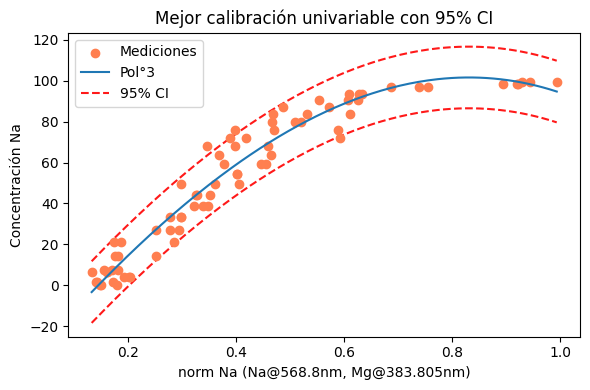

In [8]:
# ————————— Plot del mejor polinomio + banda 95% —————————
from sklearn.preprocessing import PolynomialFeatures

# extraemos lo necesario
degree = best['degree']
model  = best['model']
x      = best['x']
y      = best['y']
rmse   = best['rmse']

# reconstruyo la curva polinomial en un eje fino
pf      = PolynomialFeatures(degree, include_bias=True)
x_fine  = np.linspace(x.min(), x.max(), 200)
Xp_fine = pf.fit_transform(x_fine.reshape(-1,1))
y_curve = model.predict(Xp_fine)

# calculo banda de confianza ~ ±1.96·RMSE
ci = 1.96 * rmse

plt.figure(figsize=(6,4))
# puntos medidos
plt.scatter(x, y, label='Mediciones', zorder=5, c='coral')
# curva polinomial suave
plt.plot(x_fine, y_curve, '-', label=f"Pol°{degree}", zorder=10)
# bandas de confianza al 95%
plt.plot(x_fine, y_curve + ci, '--', alpha=0.9, label='95% CI', color = 'Red')
plt.plot(x_fine, y_curve - ci, '--', alpha=0.9,color = 'Red')
plt.xlabel(f"{best['indicator']} (Na@{best['na_peak']}nm, Mg@{best['mg_peak']}nm)")
plt.ylabel(f"Concentración {best['element']}")
plt.title("Mejor calibración univariable con 95% CI")
plt.legend()
plt.tight_layout()
plt.show()


## Generación de polinomio separando en Train/test

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

train_ratio = 0.7   # e.g. 70% train, 30% test

In [10]:
# Bucle: split, fit en train, evaluar en train/test
results = []
for na_c, mg_c in itertools.product(na_centers, mg_centers):
    na_vals = np.array([extract_peak(wavelengths, intensity_matrix[:,j], na_c, window)
                        for j in range(intensity_matrix.shape[1])])
    mg_vals = np.array([extract_peak(wavelengths, intensity_matrix[:,j], mg_c, window)
                        for j in range(intensity_matrix.shape[1])])
    for ind_name, ind_fun in indicators.items():
        ind_vals = np.array([ind_fun(n,m) for n,m in zip(na_vals, mg_vals)])
        if np.isnan(ind_vals).any(): 
            continue

        for elm_idx, elm_name in enumerate(['Na2SO4','MgSO4']):
            y = conc[:, elm_idx]
            x = ind_vals

            # split train/test
            x_tr, x_te, y_tr, y_te = train_test_split(
                x, y, train_size=train_ratio, random_state=0
            )

            for degree in (1,2,3):
                # fit sólo con training
                model, r2_tr, rmse_tr, y_tr_pred = fit_poly(x_tr, y_tr, degree)
                # evaluar test
                pf = PolynomialFeatures(degree, include_bias=True)
                y_te_pred = model.predict(pf.fit_transform(x_te.reshape(-1,1)))
                r2_te    = r2_score(y_te, y_te_pred)
                rmse_te  = np.sqrt(mean_squared_error(y_te, y_te_pred))

                results.append({
                    'na_peak':   na_c,
                    'mg_peak':   mg_c,
                    'indicator': ind_name,
                    'element':   elm_name,
                    'degree':    degree,
                    'r2_train':  r2_tr,
                    'rmse_train':rmse_tr,
                    'r2_test':   r2_te,
                    'rmse_test': rmse_te,
                    'model':     model,
                    'x_tr':      x_tr, 'y_tr': y_tr, 'y_tr_pred': y_tr_pred,
                    'x_te':      x_te, 'y_te': y_te, 'y_te_pred': y_te_pred,
                })

In [14]:
#Selección del mejor según R²_test
results.sort(key=lambda r: (-r['r2_test'], r['rmse_test']))
best = results[1]

print(f"\nBest univariable calibration (train {train_ratio*100:.0f}%):")
print(f" Elemento:     {best['element']}")
print(f" Pico Na:      {best['na_peak']} nm")
print(f" Pico Mg:      {best['mg_peak']} nm")
print(f" Indicador:    {best['indicator']}")
print(f" Grado pol.:   {best['degree']}")
print(f" R² train:     {best['r2_train']:.4f}")
print(f" RMSE train:   {best['rmse_train']:.4f}")
print(f" R² test:      {best['r2_test']:.4f}")
print(f" RMSE test:    {best['rmse_test']:.4f}")


Best univariable calibration (train 70%):
 Elemento:     MgSO4
 Pico Na:      568.8 nm
 Pico Mg:      383.805 nm
 Indicador:    norm Mg
 Grado pol.:   2
 R² train:     0.9536
 RMSE train:   7.4768
 R² test:      0.9145
 RMSE test:    8.3195


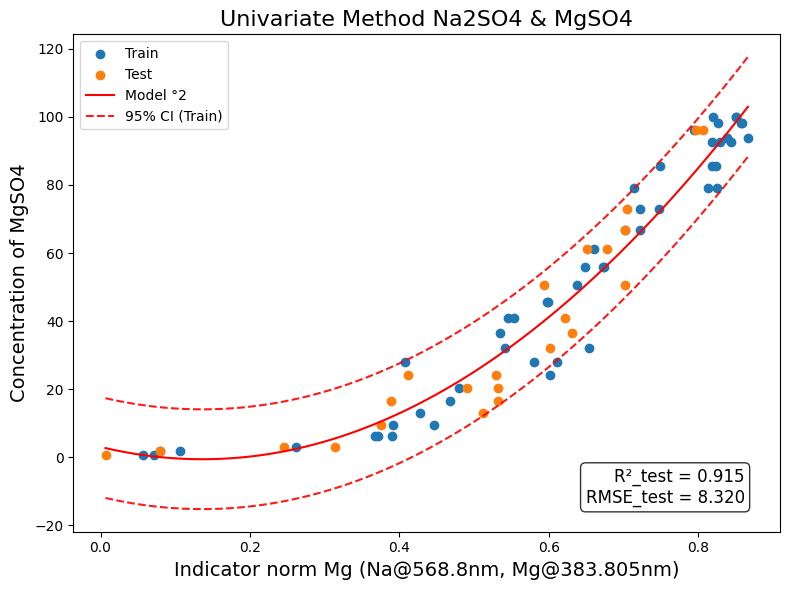

In [18]:
x_tr = best['x_tr']; y_tr = best['y_tr']
x_te = best['x_te']; y_te = best['y_te']
x_curve = np.linspace(min(x_tr.min(),x_te.min()),
                      max(x_tr.max(),x_te.max()), 200)
# Plot train vs test y curva final
rmse   = best['rmse_train']
# calculo banda de confianza ~ ±1.96·RMSE
ci = 1.96 * rmse
pf = PolynomialFeatures(best['degree'], include_bias=True)
Xp_curve = pf.fit_transform(x_curve.reshape(-1,1))
y_curve = best['model'].predict(Xp_curve)

plt.figure(figsize=(8,6))
plt.scatter(x_tr, y_tr, label='Train', color='C0')
plt.scatter(x_te, y_te, label='Test',  color='C1')
plt.plot(x_curve, y_curve, 'r-', label=f"Model °{best['degree']}")
# bandas de confianza al 95%
plt.plot(x_curve, y_curve + ci, '--', alpha=0.9, label='95% CI (Train)', color = 'Red')
plt.plot(x_curve, y_curve - ci, '--', alpha=0.9,color = 'Red')

plt.xlabel(f"Indicator {best['indicator']} (Na@{best['na_peak']}nm, Mg@{best['mg_peak']}nm)",fontsize=14)
plt.ylabel(f"Concentration of {best['element']}",fontsize=14)
plt.title("Univariate Method Na2SO4 & MgSO4",fontsize=16)
plt.legend()
# Prepara el texto con R² y RMSE de test
text_str = (
    f"R²_test = {best['r2_test']:.3f}\n"
    f"RMSE_test = {best['rmse_test']:.3f}"
)

# Colócalo en la esquina inferior izquierda en coordenadas relativas
plt.gca().text(
    0.95, 0.05, text_str,
    transform=plt.gca().transAxes,
    va='bottom', ha='right',
    fontsize=12,
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8)
)
max_x = max(x_tr.max(), x_te.max())
#plt.xlim(0, max_x)
#plt.ylim(0, 100)
plt.tight_layout()
plt.show()